In [4]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import ast

# Load both datasets
digits_df = pd.read_csv("../data/digits.csv")
more_digits_df = pd.read_csv("../data/more_digits.csv")

print("digits.csv:")
print(digits_df.head())

print("Shape:", digits_df.shape)
print("\nmore_digits.csv:")
print(more_digits_df.head())
print("Shape:", more_digits_df.shape)

digits.csv:
   label                                              image
0      0  [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...
1      0  [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...
2      6  [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...
3      0  [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...
4      2  [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...
Shape: (12449, 2)

more_digits.csv:
   label                                              image
0      3  [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...
1      9  [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...
2      0  [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...
3      0  [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...
4      7  [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...
Shape: (15741, 2)


In [6]:
# Original dataset
y_digits = digits_df["label"].to_numpy()
X_digits = np.array(
    digits_df["image"].apply(ast.literal_eval).tolist()
)

# New dataset
y_more = more_digits_df["label"].to_numpy()
X_more = np.array(
    more_digits_df["image"].apply(ast.literal_eval).tolist()
)

print("digits.csv")
print("X shape:", X_digits.shape)
print("y shape:", y_digits.shape)

print("\nmore_digits.csv")
print("X shape:", X_more.shape)
print("y shape:", y_more.shape)

digits.csv
X shape: (12449, 784)
y shape: (12449,)

more_digits.csv
X shape: (15741, 784)
y shape: (15741,)


In [7]:
def describe_dataset(name, X, y):
    print(f"\n--- {name} ---")
    print("Number of samples:", len(X))
    print("Number of pixels:", X.shape[1])
    print("Labels:", np.unique(y))
    print("Min pixel value:", X.min())
    print("Max pixel value:", X.max())
    print("Mean pixel value:", X.mean())
    print("Std pixel value:", X.std())

describe_dataset("digits.csv", X_digits, y_digits)
describe_dataset("more_digits.csv", X_more, y_more)


--- digits.csv ---
Number of samples: 12449
Number of pixels: 784
Labels: [0 1 2 3 4 5 6 7 9]
Min pixel value: 0.0
Max pixel value: 1.0
Mean pixel value: 0.12856833701808879
Std pixel value: 0.3064379734492672

--- more_digits.csv ---
Number of samples: 15741
Number of pixels: 784
Labels: [0 1 2 3 4 5 6 7 8 9]
Min pixel value: 0.0
Max pixel value: 1.0
Mean pixel value: 0.1292576650392736
Std pixel value: 0.3070033961108707


In [9]:
def class_distribution(y):
    labels, counts = np.unique(y, return_counts=True)
    return labels, counts

labels_digits, counts_digits = class_distribution(y_digits)
labels_more, counts_more = class_distribution(y_more)

comparison = pd.DataFrame({

    "digits.csv": pd.Series(y_digits).value_counts().sort_index(),

    "more_digits.csv": pd.Series(y_more).value_counts().sort_index()

}).fillna(0).astype(int)

comparison.index.name = "Label"

print(comparison)

       digits.csv  more_digits.csv
Label                             
0            1480             1776
1            1685             2022
2            1489             1787
3            1532             1839
4            1460             1752
5             271              542
6            1479             1775
7            1566             1879
8               0              585
9            1487             1784


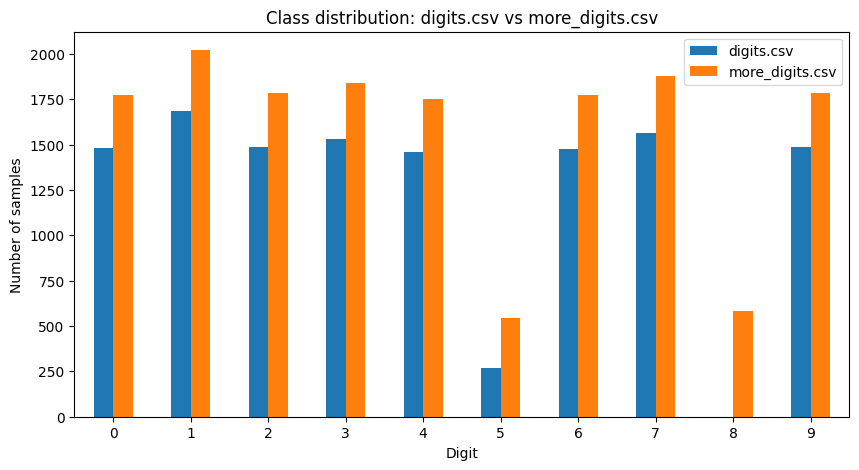

In [11]:
comparison.plot(
    kind="bar",
    figsize=(10, 5)
)

plt.xlabel("Digit")
plt.ylabel("Number of samples")
plt.title("Class distribution: digits.csv vs more_digits.csv")
plt.xticks(rotation=0)
plt.show()


Initial Data Exploration

The original digits.csv dataset contains 12,449 samples, while the new more_digits.csv dataset contains 15,741 samples. Both datasets represent 28×28 pixel images, resulting in 784 input features per sample. Pixel values are already scaled between 0 and 1, and the two datasets have very similar overall pixel distributions.

A notable difference is found in the class distribution. The original digits.csv dataset contains no samples of digit 8 and only 271 samples of digit 5, while most other classes contain approximately 1,450–1,700 samples. In contrast, more_digits.csv contains all ten digit classes, including 585 samples of digit 8 and 542 samples of digit 5.

This difference may be particularly relevant when comparing the performance of Exercises 2 and 3. A model trained only on digits.csv has no training examples from class 8 and relatively few examples from class 5. The additional data in more_digits.csv therefore not only increases the total amount of training data, but also changes the class coverage and provides examples from a previously unseen class. This is an important factor to consider when analyzing why performance changes in Exercise 3, independently of changes to the model or training techniques.